In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pysam import AlignmentFile
import pysam
from scipy.signal import savgol_filter
from matplotlib import gridspec
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import json

from cuban_lib.visualize import plot_breakpoints_ill_pb, plot_breakpoints_ill
from cuban_lib.utils import compute_baseline_cov

plt.style.use('ggplot')

In [2]:
# Load repeat annotations
repeats = '/confidential/tGenVar/ref/hg38/annotation/hg38_repeatmasker.tsv'
repeat_df = pd.read_csv(repeats, sep='\t')

In [3]:
# Region
sv_type = 'DUP'
chrom = 'chr11'
start = 105077001
stop = 105107140

# Samples from cohort
"""
cohort_samples = {'16-110' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-110/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30},
                  '16-112' : {'family_status' : 'father',
                              'disease_status' : 'unaffected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-112/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30},
                  '16-113' : {'family_status' : 'mother',
                              'disease_status' : 'unaffected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/typo/cohorts/Udd/aligned_bam/16-113/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}"""
                              
cohort_samples = {'17-01' : {'family_status' : 'index',
                              'disease_status' : 'affected',
                              'technology' : 'ill',
                              'bam_name' : f'/confidential/iGenVar/Unsolved_cases/WGS/aligned_bam/17-01/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                              'baseline_cov' : 30}}

# Load baseline coverage for control samples
with open('resources/baseline_cov_ill.json', 'r') as f:
    baseline_cov_ill = json.load(f)
with open('resources/baseline_cov_pb.json', 'r') as f:
    baseline_cov_pb = json.load(f)

# Samples from control
control_samples = {'HG002 - Illumina' : {'family_status' : 'control',
                                         'disease_status' : 'unaffected',
                                         'technology' : 'ill',
                                         'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/ill/bam/GRCh38.bwa_mem.pe.sorted.mdup.recal.bam',
                                         'baseline_cov' : baseline_cov_ill[chrom]},
                   'HG002 - PacBio HiFi' : {'family_status' : 'control',
                                            'disease_status' : 'unaffected',
                                            'technology' : 'pb',
                                            'bam_name' : '/confidential/FamilyR13/DATA/10x/SCRIPT/tGenVar/svdb/data/raw/1kg/hg38/HG002/pb_hifi/bam/HG002_GRCh38.haplotag.10x.bam',
                                            'baseline_cov' : baseline_cov_pb[chrom]}}

samples = {**cohort_samples, **control_samples}

In [4]:
rep_y_pos_map = {'LINE' : (-6, '#6ac0b7'),
                 'SINE' : (-14, '#b7954b'),
                 'LTR' : (-22, '#f0b6a0'),
                 'DNA' : (-30, '#5066a2'),
                 'Simple_repeat' : (-38, '#504669'),
                 'Satellite' : (-46, '#df624c'),
                 'Low_complexity' : (-54, '#61856b'),
                 'Retroposon' : (-62, '#2f7155')}

[  109   821   865  2418  4438  5278  5507  7354  7608  7942  8592 10276
 11449 12883 13142 13526 16278 22315 22485 28085 28368 34109 34236 35499
 37297 37471 39781 41648]
[  465   539   539   890   939  2967  3117  3874  4211  6435  6474  7559
  9661 13199 16604 16710 18656 18695 18695 18773 18773 19012 19424 20428
 20428 20526 20526 23406 23664 24998 27003 27440 31653 31839 32184 34725
 37367 37697 38781 39170]
[ 6027  6037  6037  6041  6041  6050  6054  6056  6059  6077  6080  6080
  6081  6081  6082  6090  6097  6104  6116  6827 35698 35698 35702 35774
 35774 35774 35774 35795 35795 35840 35899 35944 35953 35957 35959 35959
 36010 36011 36016]


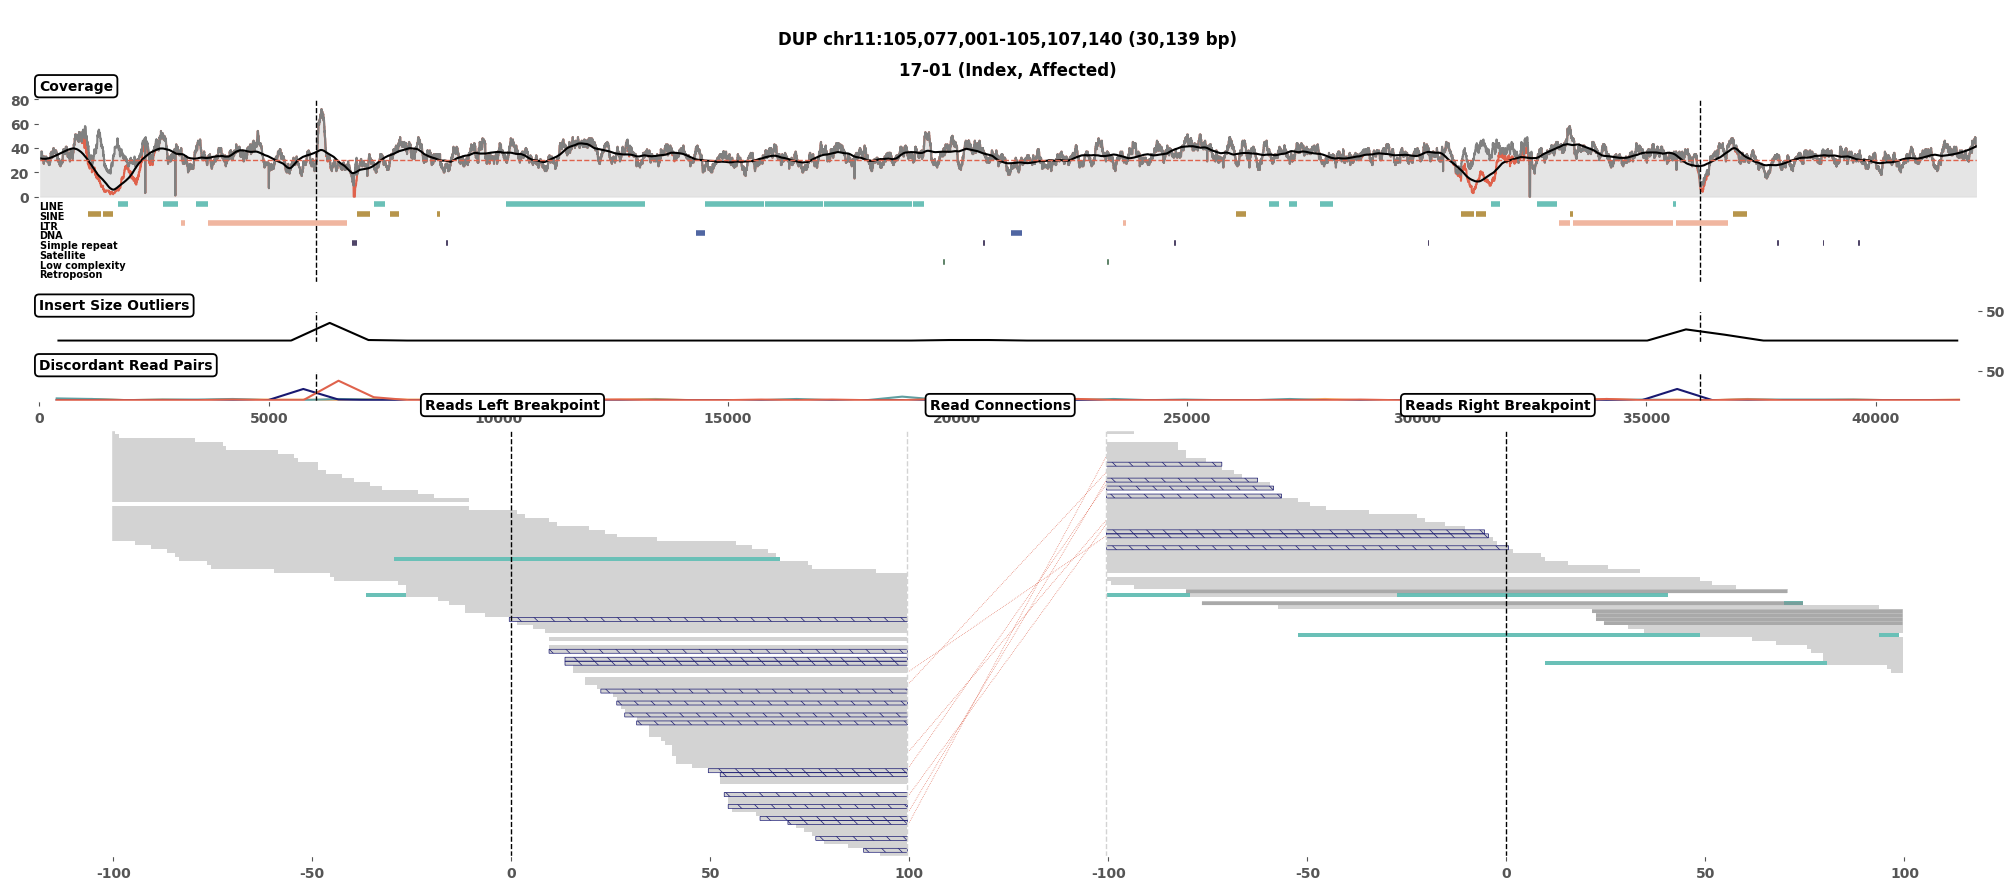

In [5]:
plot_breakpoints_ill(cohort_samples, repeat_df, sv_type, chrom, start, stop, padding=1500, window=100, collapse_ins=False)